In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"
#import gym
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
from collections import deque
import random
import pdb
import plotly.express as px
import plotly.graph_objects as go
import pickle
import scipy.io
from matplotlib.font_manager import FontProperties
import pandas as pd
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from tqdm import tqdm
import matplotlib.animation as animation
import glob
#from natsort import natsorted
from PIL import Image

def create_gif(pth, time_ind):
    #files = glob.glob(r"./imgs/*.png")
    files = glob.glob(os.path.join(pth,'*.png'))
    files = natsorted(files)
    image_array = []
    
    def update(i):
        im.set_array(image_array[i])
        return im, 
    
    for my_file in files:

        image = Image.open(my_file)
        image_array.append(image)
    
    # Create the figure and axes objects
    fig, ax = plt.subplots()

    # Set the initial image
    im = ax.imshow(image_array[0], animated=True)
    
    animation_fig = animation.FuncAnimation(fig, update, frames=len(image_array), interval=100, blit=True,repeat_delay=10,)

    # Show the animation
    #plt.show()

    #animation_fig.save("./imgs/animated_{}.gif".format(time_ind))
    animation_fig.save(os.path.join(pth,'animated_{}.gif').format(time_ind))
    pass

### Adding gamma_0 value for SINR computation ####

$\gamma = \frac{|h|_s^2P_t}{|h|_i^2P_t + N_0B}$

Assuming power transmitted power is same from all BSs then we have 

$\gamma = \frac{|h|_s^2}{|h|_i^2 + \frac{1}{\gamma_0}}$


where $\gamma_0 = P_t/N_0B$, you can assume P_t = 10 dBm, and the below calculations for $N_0$

In [2]:
## transmit power ###
Pt_dBm = 10  # Transmit power in dBm

#### Noise power ####
k = 1.38e-23  # Boltzmann's constant
T = 290       # Temperature in Kelvin
B = 10e6       # Bandwidth in Hz

# Calculate noise spectral density in Watts/Hz
Noise_spectral_density = k * T

# Convert noise spectral density to dBm/Hz
# Convert to Watts first then to dBm (1 mW = 0.001 W)
Noise_spectral_density_W = Noise_spectral_density * 1000  # Convert to mW
Noise_spectral_density_dBm = 10 * np.log10(Noise_spectral_density_W)
print('Noise_spectral_density_dBm', Noise_spectral_density_dBm)

# Calculate total noise power in Watts then convert to dBm
N_thermal = Noise_spectral_density * B  # Total noise power in Watts
N_thermal_dBm = 10 * np.log10(N_thermal * 1000)  # Convert noise power to dBm
print('thermal_noise_power(dBm)', N_thermal_dBm)

##### gamma_0 in dB ############
gamma_0_dB = Pt_dBm - N_thermal_dBm  # Calculate SNR in dB
#print('gamma_0 (dB)', gamma_0_dB)

##### gamma_0 ######
gamma_0 = np.power(10, gamma_0_dB/10)
print('1/gamma_0', 1/gamma_0)

Noise_spectral_density_dBm -173.97722915699805
thermal_noise_power(dBm) -103.97722915699808
1/gamma_0 4.001999999999999e-12


### 
CDF of SINR computed for F($\gamma$), for different channel realizations,
below is when the the device is at a mean distance of 1m from the serving BS with a standard deviation of 0.1 m, and mean distance from the interfering BS at 4 meters with std of 0.1m 

In [3]:
def return_cdf(a):
    sorted_a = np.sort(a)
    cdf = np.arange(1, len(sorted_a) + 1) / len(sorted_a)
    return sorted_a, cdf

In [4]:
############## Creating distances intra and inter ########
M = 8 # number of sub-networks 
Ts = 10000 # number of time slots
J = 3 # number of devices
f_c = 1.3 #GHz
N = 20
TxRxds = np.zeros((Ts, M, M*J))
d_intra = np.abs(np.random.normal(0.5,0.1,M*J))
d_intra = np.reshape(d_intra, (M,J))

In [5]:
def generate_random_point(grid_size):
    return np.random.uniform(0, grid_size, 2)

def generate_random_velocity():
    angle = np.random.uniform(0, 2 * np.pi)
    velocity = 11.11  # 40 km/h in m/s
    return np.array([velocity * np.cos(angle), velocity * np.sin(angle)])

def is_within_grid(point, grid_size):
    return all(0 <= coord <= grid_size for coord in point)

def handle_boundary_collisions(point, grid_size):
    angle = np.random.uniform(0, 2 * np.pi)
    velocity = 11.11
    if point[0] <= 0 or point[0] >= grid_size:
        angle = np.pi - angle if point[0] <= 0 else -angle
    if point[1] <= 0 or point[1] >= grid_size:
        angle = -np.pi / 2 - angle if point[1] <= 0 else np.pi / 2 - angle
    return np.array([velocity * np.cos(angle), velocity * np.sin(angle)])

def handle_ap_collisions(points, velocities, min_distance):
    for i in range(len(points)):
        for j in range(i + 1, len(points)):
            if np.linalg.norm(points[i] - points[j]) < min_distance:
                # Adjust direction randomly for both APs
                velocities[i] = generate_random_velocity()
                velocities[j] = generate_random_velocity()
    return velocities

def update_positions(points, velocities, tau, grid_size, min_distance):
    new_points = points + velocities * tau
    for i, point in enumerate(new_points):
        if not is_within_grid(point, grid_size):
            velocities[i] = handle_boundary_collisions(point, grid_size)
        new_points[i] = points[i] + velocities[i] * tau  # Recalculate with new velocity
    velocities = handle_ap_collisions(new_points, velocities, min_distance)
    return new_points, velocities

# Initialize parameters
grid_size = 20
num_points = M
min_distance = 2
tau = 0.01  # time interval in seconds

# Initialize points and velocities
points = np.array([generate_random_point(grid_size) for _ in range(num_points)])
velocities = np.array([generate_random_velocity() for _ in range(num_points)])
init_cents = points
# Simulation loop for 20 time steps
pth = r'C:\Users\sriniva3\OneDrive - Aalto University\Simulations\RL framework URLLC\RL framework_V2.0_DDPG\imgs'
#Ts = 1000
sub_net_cents = np.zeros((Ts+1, num_points, 2))
sub_net_cents[0] = init_cents
for step in tqdm(range(Ts-1)):
    points, velocities = update_positions(points, velocities, tau, grid_size, min_distance)
    sub_net_cents[step+1] = points
    '''
    # Plotting for visualization
    plt.figure(figsize=(3, 3))
    plt.scatter(points[:, 0], points[:, 1], c='red', label=f'Time Step {step+1}')
    plt.xlim(0, grid_size)
    plt.ylim(0, grid_size)
    plt.grid(True)
    plt.title(f'Access Points at Step {step+1}')
    plt.xlabel('Meters')
    plt.ylabel('Meters')
    #plt.legend()
    plt.savefig(os.path.join(pth, '{}.png'.format(step)))
    plt.close()
    #plt.show()
    ''';
#create_gif(pth, step)

100%|██████████| 9999/9999 [00:01<00:00, 5496.24it/s]


In [6]:
d_relative_locs = {}
for i in range(M):
    d_angle = np.random.uniform(0,2*np.pi,J) 
    d_r = np.random.uniform(0, 1, J)
    d_relative_locs[i] = np.vstack([d_r*np.cos(d_angle), d_r*np.sin(d_angle)])

In [7]:
def return_euclid_dist(device_x_coord, device_y_coord, AP_x_coord, AP_y_coord):
    device_coords = np.array([device_x_coord, device_y_coord])
    AP_coords = np.array([AP_x_coord, AP_y_coord])
    return np.linalg.norm(device_coords - AP_coords)

x_coords_ts, y_coords_ts = {}, {}
for ts in range(Ts):
    coords = sub_net_cents[ts]
    point_xs, point_ys = [], []
    for k in d_relative_locs.keys():
        point_x = d_relative_locs[k][0] + coords[k][0]
        point_y = d_relative_locs[k][1] + coords[k][1]
        #print(point_x, point_y)
        point_xs.append(point_x)
        point_ys.append(point_y)
    #break    
    x_coords_ts[ts] = point_xs
    y_coords_ts[ts] = point_ys

In [8]:
TxRxds = np.zeros((Ts, M, M*J))
for ts in range(Ts):
    device_x_coords, device_y_coords = np.array(x_coords_ts[ts]), np.array(y_coords_ts[ts])
    device_x_coords, device_y_coords = device_x_coords.flatten(), device_y_coords.flatten()
    AP_x_coords, AP_y_coords = sub_net_cents[ts][:,0], sub_net_cents[ts][:,1]
    
    #for dx in device_x_coords 
    dists = np.zeros((M,M*J))
    for i in range(AP_x_coords.shape[0]):
        dist = []
        for j in range(len(device_x_coords.flatten())):
            #dist = []
            #print(i,j)
            dist.append(return_euclid_dist(device_x_coords[j], device_y_coords[j], AP_x_coords[i], AP_y_coords[i]))
            #print(dist)
        dists[i] = np.array(dist)
    TxRxds[ts] = dists
    #break

#dist = return_euclid_dist(x_coords_ts[0], y_coords_ts[0], AP_x_coord, AP_y_coord)

(array([326512., 222620., 298382., 304650., 288244., 220262., 142064.,
         74271.,  33178.,   9817.]),
 array([1.07643777e-02, 3.43878086e+00, 6.86679733e+00, 1.02948138e+01,
        1.37228303e+01, 1.71508468e+01, 2.05788632e+01, 2.40068797e+01,
        2.74348962e+01, 3.08629127e+01, 3.42909292e+01]),
 <BarContainer object of 10 artists>)

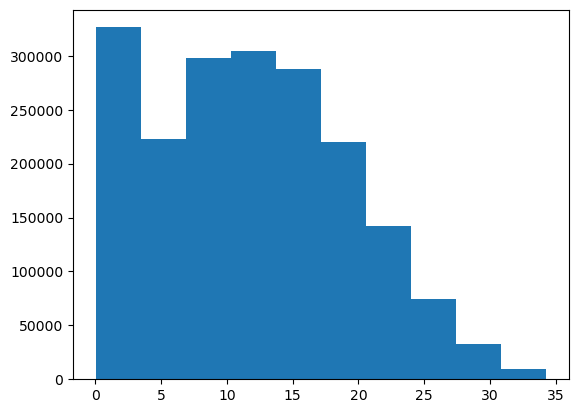

In [9]:
plt.hist(TxRxds.flatten())

In [10]:
TxRxds.shape

(10000, 8, 24)

### Using Jakes model 

In [11]:

def return_jakes_coeffcients(fd_max, TimeVaris, n_links = 5, plot = True):
    ff_gains, TimeSequences = [], []
    rays = 100
    for i in tqdm(range(n_links)):    
        #TimeVaris = np.arange(0,50,0.0005)
        #TimeVaris = np.arange(0,.2,0.005)
        frequs = np.sort(np.array([np.round(fd_max*np.cos(2*np.pi*np.random.uniform(0,1))) for _ in range(rays)]))
        phases = np.array([np.exp(1j*2*np.pi*np.random.uniform(0,1)) for _ in range(rays)])

        TimeSequence = []
        for t in TimeVaris:
            tab = np.exp(1j*2*np.pi*frequs*t)
            tabrot = tab*phases
            fun = np.sum(tabrot)
            TimeSequence.append(fun)
        TimeSequence = np.array(TimeSequence)

        #TimeSequence = TimeSequence/np.linalg.norm(TimeSequence)*np.sqrt(len(TimeSequence))
        PowerSequence1 =  np.abs(TimeSequence)**2;
        #plt.plot(TimeVaris[0:200], 10*np.log10(PowerSequence1)[0:200])
        ff_gains.append(PowerSequence1)
        TimeSequences.append(TimeSequence)
    ff_gains = np.array(ff_gains)/rays
    TimeSequences = np.array(TimeSequences)
    if plot:
        plt.plot(TimeVaris[0:200], 10*np.log10(ff_gains[0])[0:200])
        plt.show()
    return ff_gains, TimeSequences

v = 40 #kmph 
v_ms = v*5/18
c = 3*1e8
tau = .01
fd_max = v_ms*f_c*1e9/c
TimeVaris = np.arange(0,5,5/Ts)

ff_gains, TimeSequences = return_jakes_coeffcients(fd_max, TimeVaris, n_links = M*(M-1)*J*N, plot = False)
#plt.plot(TimeVaris[0:Ts], 10*np.log10(ff_gains.flatten()[0:Ts]))
#plt.show()

100%|██████████| 3360/3360 [07:09<00:00,  7.82it/s]


In [12]:
#np.save( 'ff_gains_int_power.npy',ff_gains)
#ff_gains = np.load('ff_gains.npy')

In [13]:
############ fast fading coeffecients ########

K = 4  # Rician K-factor

# Compute LOS and NLOS scaling factors
LOS_scale = np.sqrt(K / (K + 1))  # LOS component scaling
NLOS_scale = np.sqrt(1 / (K + 1))  # NLOS component scaling
# Generate LOS component
random_phase = np.exp(1j * 2 * np.pi * np.random.rand(M, J, N))  # Same random phase for all elements
LOS_component = LOS_scale * np.ones((M, J, N)) * random_phase
# Generate NLOS component
NLOS_component = NLOS_scale * (np.random.normal(0, 1 / np.sqrt(2), (M, J, N)) +
                               1j * np.random.normal(0, 1 / np.sqrt(2), (M, J, N)))
# Combine LOS and NLOS components
FastFadingChannels = LOS_component + NLOS_component

#FastFadingChannels = np.random.normal(0,1/np.sqrt(2), M*J*N) + 1j*np.random.normal(0,1/np.sqrt(2), M*J*N)
FastFadingChannels = np.reshape(FastFadingChannels,(M,J,N))
FadingGains = np.abs(FastFadingChannels)**2
#all_SINRsdB, all_MeansPerSubNW, all_DiffsFromMean = np.zeros((Ts, M*J)), np.zeros((Ts, M)), np.zeros((Ts, M*J))
all_SINRsdB = np.zeros((Ts, M,J,N))
alltime_WantedSigPerDev, alltime_InterfPowsPerDev = [], []
for ts in range(Ts):
    

    #FadingGains.shape

    all_fast_fading_gains = np.zeros((M,M*J,N))
    for m in range(M):
        jakes_coeffs = ff_gains[:,ts]
        jakes_coeffs = np.reshape(jakes_coeffs,(M,(M-1)*J,N))
        all_fast_fading_gains[m] = np.concatenate([FadingGains[m], jakes_coeffs[m]])
    all_fast_fading_gains = np.array(all_fast_fading_gains)
    
    PL_los = 31.84 +21.5*np.log10(TxRxds[ts]) + 19*np.log10(f_c)
    PL = 33+25.5*np.log10(TxRxds[ts])+20*np.log10(f_c)
    PL_nlos = np.max((PL_los, PL), axis = 0)
    PathGains = np.power(10, -PL_nlos/10)
    PathGains = np.repeat(PathGains[:, :, np.newaxis], N, axis=2)

    ##### Compute total path gains ########
    #pdb.set_trace()
    PathGainsTot = PathGains*all_fast_fading_gains

    #### Compute WantedSigPerDev ######
    WantedSigPerDev = np.zeros((M,J,N))
    for m in range(M):
        WantedSigPerDev[m] = PathGainsTot[m,m*J:(m+1)*J]
    alltime_WantedSigPerDev.append(WantedSigPerDev)
    InterfPowsPerDev = np.zeros((M,J,N))
    for m in range(M):
        Interferers = [i for i in range(M) if i!=m]
        Devs = np.arange(m*J,(m+1)*J)
        #print(Interferers, Devs)
        InterfPowGains = PathGainsTot[np.ix_(Interferers, Devs)]
        InterfPowsPerDev[m,] = np.sum(InterfPowGains, axis = 0)
    alltime_InterfPowsPerDev.append(InterfPowsPerDev)
    SINRs = WantedSigPerDev/(InterfPowsPerDev + 1/gamma_0);
    SINRsdB = 10*np.log10(SINRs)
    all_SINRsdB[ts,:] = SINRsdB
alltime_WantedSigPerDev = np.array(alltime_WantedSigPerDev)
alltime_InterfPowsPerDev = np.array(alltime_InterfPowsPerDev)
all_Int_pows_dBm = 10*np.log10(alltime_InterfPowsPerDev)

In [14]:
alltime_InterfPowsPerDev.shape

(10000, 8, 3, 20)

In [15]:
WantedSigPerDev.shape

(8, 3, 20)

-50.05219636801532


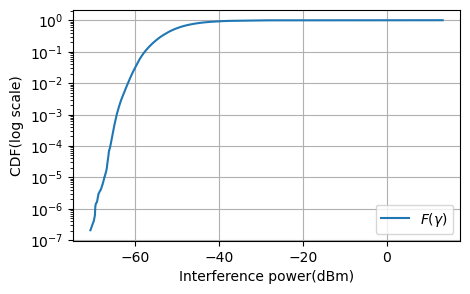

In [16]:
a1, cdf1 = return_cdf(all_Int_pows_dBm.flatten())
plt.figure(figsize= [5,3])
#plt.ylim(np.min(cdf2))
plt.semilogy(a1, cdf1, label = r'$F(\gamma)$')
plt.grid()
plt.xlabel('Interference power(dBm)')
plt.ylabel('CDF(log scale)')
plt.legend()
print(np.mean(all_Int_pows_dBm.flatten()))

22.307308710882165


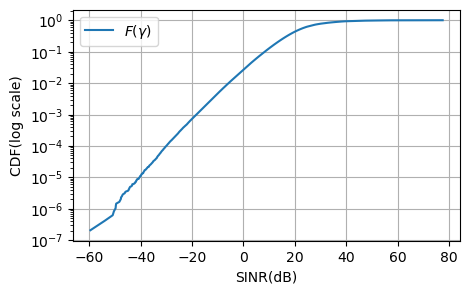

In [17]:
a1, cdf1 = return_cdf(all_SINRsdB.flatten())
plt.figure(figsize= [5,3])
#plt.ylim(np.min(cdf2))
plt.semilogy(a1, cdf1, label = r'$F(\gamma)$')
plt.grid()
plt.xlabel('SINR(dB)')
plt.ylabel('CDF(log scale)')
plt.legend()
print(np.mean(all_SINRsdB.flatten()))

9.351441510829094


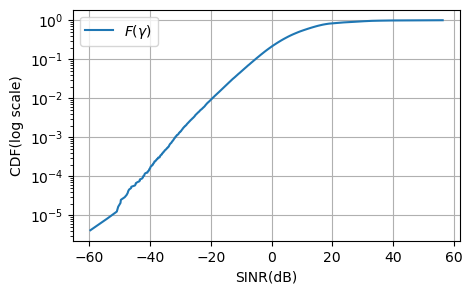

In [18]:
alltime_SINRsdB_combined = []
all_SINRslin = np.power(10, all_SINRsdB/10)
for ts in range(all_SINRsdB.shape[0]):
    vals = all_SINRslin[ts,:,:,:]
    SINRS_combined = np.min(vals, axis = 2)
    SINRsdB_combined = 10*np.log10(SINRS_combined)
    alltime_SINRsdB_combined.append(SINRsdB_combined)
alltime_SINRsdB_combined = np.array(alltime_SINRsdB_combined)

a1, cdf1 = return_cdf(alltime_SINRsdB_combined.flatten())
plt.figure(figsize= [5,3])
#plt.ylim(np.min(cdf2))
plt.semilogy(a1, cdf1, label = r'$F(\gamma)$')
plt.grid()
plt.xlabel('SINR(dB)')
plt.ylabel('CDF(log scale)')
plt.legend()
print(np.mean(alltime_SINRsdB_combined.flatten()))

In [19]:
all_SINRsdB.shape

(10000, 8, 3, 20)

### The below model needs to be integrated with DRL framework trained paralelly. 


##### prediction of SINR at t given 10 previous time slots #########
####### 10000 x 5x 5 x 30, 10000 is time slots, first 5 denotes the sub networks, 2nd 5 denotes the devices of a sub network, 
####### 30 denotes the channel resources. 


#### preparing data for a sub-network ########
######## each sub-network will have one LSTM layer getting trained in parallel with the main DRL agent ########
######### i.e., the LSTM layer is trained for a given example with a loss function and predicted SINR is given as the 
######### input to the DRL framework which is subsequently trained. This happens in an online fashion at every time-slot.

In [20]:
## data for a sub-network 
lag = 10
inp_data, out_data = [], []
for i in range(M):
    sinr_sub_nw = all_Int_pows_dBm[:,0,:,:]
    data_per_device = sinr_sub_nw[:,0,:]
    for t in range(0, len(data_per_device)-lag):
        inp_data.append(data_per_device[t:t+lag])
        out_data.append(data_per_device[t+lag])

    
inp_data = np.array(inp_data)
out_data = np.array(out_data)

In [21]:
class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers):
        super(LSTMModel, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
        # Define the LSTM layer
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        
        # Define the output layer
        self.fc = nn.Linear(hidden_dim, output_dim)
    
    def forward(self, x):
        # Initialize hidden state with zeros
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        
        # Initialize cell state with zeros
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        
        # Forward propagate LSTM
        out, _ = self.lstm(x, (h0, c0))
        
        # Decode the hidden state of the last time step
        out = self.fc(out[:, -1, :])
        return out

In [22]:
samp_no = int(0.95*len(inp_data))
inp_train_data = inp_data[0:samp_no]
out_train_data = out_data[0:samp_no]
inp_test_data = inp_data[samp_no:]
out_test_data = out_data[samp_no:]

# Convert numpy arrays to PyTorch tensors
inp_train_data = torch.tensor(inp_train_data, dtype=torch.float32)
out_train_data = torch.tensor(out_train_data, dtype=torch.float32)
inp_test_data = torch.tensor(inp_test_data, dtype=torch.float32)
out_test_data = torch.tensor(out_test_data, dtype=torch.float32)


inp_test_data 
# Create a dataset and dataloader
train_dataset = TensorDataset(inp_train_data, out_train_data)
train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)


In [23]:
# Set device (CPU or GPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Model parameters
input_dim = N
hidden_dim = 128
output_dim = N
num_layers = 1
num_epochs = 50
learning_rate = 1e-3

# Initialize the model, loss function and optimizer
model = LSTMModel(input_dim, hidden_dim, output_dim, num_layers).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
epoch_loss = []
# Training loop
for epoch in tqdm(range(num_epochs)):
    for i, (inputs, targets) in enumerate(train_loader):
        inputs = inputs.to(device)
        targets = targets.to(device)
        
        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        
        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss.append(loss.item())
        #if (i+1) % 100 == 0:
        #print(f'Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{len(train_loader)}], Loss: {loss.item():.4f}')


100%|██████████| 50/50 [22:43<00:00, 27.28s/it]


Epoch [1/50], Step [764/1483], Loss: 11.3486
Epoch [1/50], Step [765/1483], Loss: 14.8334
Epoch [1/50], Step [766/1483], Loss: 17.5724
Epoch [1/50], Step [767/1483], Loss: 13.0317
Epoch [1/50], Step [768/1483], Loss: 14.4637
Epoch [1/50], Step [769/1483], Loss: 10.1809
Epoch [1/50], Step [770/1483], Loss: 12.6517
Epoch [1/50], Step [771/1483], Loss: 10.0039
Epoch [1/50], Step [772/1483], Loss: 14.2583
Epoch [1/50], Step [773/1483], Loss: 12.8976
Epoch [1/50], Step [774/1483], Loss: 11.9408
Epoch [1/50], Step [775/1483], Loss: 12.8508
Epoch [1/50], Step [776/1483], Loss: 12.2862
Epoch [1/50], Step [777/1483], Loss: 12.8324
Epoch [1/50], Step [778/1483], Loss: 10.6604
Epoch [1/50], Step [779/1483], Loss: 11.5792
Epoch [1/50], Step [780/1483], Loss: 19.5885
Epoch [1/50], Step [781/1483], Loss: 14.4246
Epoch [1/50], Step [782/1483], Loss: 15.3229
Epoch [1/50], Step [783/1483], Loss: 10.4498
Epoch [1/50], Step [784/1483], Loss: 15.7658
Epoch [1/50], Step [785/1483], Loss: 16.7730
Epoch [1/5

Epoch [1/50], Step [964/1483], Loss: 4.3034
Epoch [1/50], Step [965/1483], Loss: 6.1560
Epoch [1/50], Step [966/1483], Loss: 5.5951
Epoch [1/50], Step [967/1483], Loss: 6.2164
Epoch [1/50], Step [968/1483], Loss: 8.9500
Epoch [1/50], Step [969/1483], Loss: 6.0578
Epoch [1/50], Step [970/1483], Loss: 5.0071
Epoch [1/50], Step [971/1483], Loss: 7.0669
Epoch [1/50], Step [972/1483], Loss: 6.4502
Epoch [1/50], Step [973/1483], Loss: 6.5869
Epoch [1/50], Step [974/1483], Loss: 8.5675
Epoch [1/50], Step [975/1483], Loss: 7.5692
Epoch [1/50], Step [976/1483], Loss: 5.5588
Epoch [1/50], Step [977/1483], Loss: 6.9544
Epoch [1/50], Step [978/1483], Loss: 6.4228
Epoch [1/50], Step [979/1483], Loss: 6.3875
Epoch [1/50], Step [980/1483], Loss: 10.0280
Epoch [1/50], Step [981/1483], Loss: 5.8130
Epoch [1/50], Step [982/1483], Loss: 5.2800
Epoch [1/50], Step [983/1483], Loss: 5.9863
Epoch [1/50], Step [984/1483], Loss: 5.5141
Epoch [1/50], Step [985/1483], Loss: 5.8801
Epoch [1/50], Step [986/1483], 

Epoch [1/50], Step [1157/1483], Loss: 6.5369
Epoch [1/50], Step [1158/1483], Loss: 4.5617
Epoch [1/50], Step [1159/1483], Loss: 5.8942
Epoch [1/50], Step [1160/1483], Loss: 5.7005
Epoch [1/50], Step [1161/1483], Loss: 7.8116
Epoch [1/50], Step [1162/1483], Loss: 5.9077
Epoch [1/50], Step [1163/1483], Loss: 4.6155
Epoch [1/50], Step [1164/1483], Loss: 4.5873
Epoch [1/50], Step [1165/1483], Loss: 6.8330
Epoch [1/50], Step [1166/1483], Loss: 5.4485
Epoch [1/50], Step [1167/1483], Loss: 3.9443
Epoch [1/50], Step [1168/1483], Loss: 5.6767
Epoch [1/50], Step [1169/1483], Loss: 5.4580
Epoch [1/50], Step [1170/1483], Loss: 5.3198
Epoch [1/50], Step [1171/1483], Loss: 5.3234
Epoch [1/50], Step [1172/1483], Loss: 4.2671
Epoch [1/50], Step [1173/1483], Loss: 5.8840
Epoch [1/50], Step [1174/1483], Loss: 4.3506
Epoch [1/50], Step [1175/1483], Loss: 5.8856
Epoch [1/50], Step [1176/1483], Loss: 4.2669
Epoch [1/50], Step [1177/1483], Loss: 6.8565
Epoch [1/50], Step [1178/1483], Loss: 4.6575
Epoch [1/5

Epoch [1/50], Step [1355/1483], Loss: 3.9725
Epoch [1/50], Step [1356/1483], Loss: 5.0980
Epoch [1/50], Step [1357/1483], Loss: 4.3183
Epoch [1/50], Step [1358/1483], Loss: 3.6944
Epoch [1/50], Step [1359/1483], Loss: 3.3246
Epoch [1/50], Step [1360/1483], Loss: 3.5389
Epoch [1/50], Step [1361/1483], Loss: 4.1346
Epoch [1/50], Step [1362/1483], Loss: 4.8128
Epoch [1/50], Step [1363/1483], Loss: 3.8384
Epoch [1/50], Step [1364/1483], Loss: 3.4664
Epoch [1/50], Step [1365/1483], Loss: 3.2958
Epoch [1/50], Step [1366/1483], Loss: 4.1216
Epoch [1/50], Step [1367/1483], Loss: 5.3127
Epoch [1/50], Step [1368/1483], Loss: 4.3911
Epoch [1/50], Step [1369/1483], Loss: 3.7958
Epoch [1/50], Step [1370/1483], Loss: 3.6525
Epoch [1/50], Step [1371/1483], Loss: 4.0952
Epoch [1/50], Step [1372/1483], Loss: 3.3794
Epoch [1/50], Step [1373/1483], Loss: 4.9333
Epoch [1/50], Step [1374/1483], Loss: 4.2587
Epoch [1/50], Step [1375/1483], Loss: 5.0470
Epoch [1/50], Step [1376/1483], Loss: 5.4978
Epoch [1/5

...

Epoch [50/50], Step [596/1483], Loss: 0.2297
Epoch [50/50], Step [597/1483], Loss: 0.2537
Epoch [50/50], Step [598/1483], Loss: 2.3128
Epoch [50/50], Step [599/1483], Loss: 0.2152
Epoch [50/50], Step [600/1483], Loss: 0.7040
Epoch [50/50], Step [601/1483], Loss: 0.7709
Epoch [50/50], Step [602/1483], Loss: 0.2977
Epoch [50/50], Step [603/1483], Loss: 0.3569
Epoch [50/50], Step [604/1483], Loss: 0.2725
Epoch [50/50], Step [605/1483], Loss: 0.6602
Epoch [50/50], Step [606/1483], Loss: 0.5243
Epoch [50/50], Step [607/1483], Loss: 0.4011
Epoch [50/50], Step [608/1483], Loss: 0.2001
Epoch [50/50], Step [609/1483], Loss: 0.3521
Epoch [50/50], Step [610/1483], Loss: 0.4357
Epoch [50/50], Step [611/1483], Loss: 0.8016
Epoch [50/50], Step [612/1483], Loss: 0.5901
Epoch [50/50], Step [613/1483], Loss: 0.1893
Epoch [50/50], Step [614/1483], Loss: 0.4534
Epoch [50/50], Step [615/1483], Loss: 0.1650
Epoch [50/50], Step [616/1483], Loss: 0.2488
Epoch [50/50], Step [617/1483], Loss: 0.3959
Epoch [50/

Epoch [50/50], Step [782/1483], Loss: 0.1688
Epoch [50/50], Step [783/1483], Loss: 0.2252
Epoch [50/50], Step [784/1483], Loss: 0.4090
Epoch [50/50], Step [785/1483], Loss: 0.4709
Epoch [50/50], Step [786/1483], Loss: 0.2304
Epoch [50/50], Step [787/1483], Loss: 0.6496
Epoch [50/50], Step [788/1483], Loss: 0.3493
Epoch [50/50], Step [789/1483], Loss: 0.4086
Epoch [50/50], Step [790/1483], Loss: 0.5602
Epoch [50/50], Step [791/1483], Loss: 0.3443
Epoch [50/50], Step [792/1483], Loss: 0.3138
Epoch [50/50], Step [793/1483], Loss: 0.3061
Epoch [50/50], Step [794/1483], Loss: 0.2862
Epoch [50/50], Step [795/1483], Loss: 0.4732
Epoch [50/50], Step [796/1483], Loss: 0.3703
Epoch [50/50], Step [797/1483], Loss: 0.5042
Epoch [50/50], Step [798/1483], Loss: 0.3840
Epoch [50/50], Step [799/1483], Loss: 0.7159
Epoch [50/50], Step [800/1483], Loss: 0.1891
Epoch [50/50], Step [801/1483], Loss: 0.2990
Epoch [50/50], Step [802/1483], Loss: 0.1487
Epoch [50/50], Step [803/1483], Loss: 0.2155
Epoch [50/

Epoch [50/50], Step [969/1483], Loss: 0.3621
Epoch [50/50], Step [970/1483], Loss: 0.3367
Epoch [50/50], Step [971/1483], Loss: 0.5817
Epoch [50/50], Step [972/1483], Loss: 0.2515
Epoch [50/50], Step [973/1483], Loss: 0.5848
Epoch [50/50], Step [974/1483], Loss: 0.2015
Epoch [50/50], Step [975/1483], Loss: 0.4200
Epoch [50/50], Step [976/1483], Loss: 0.4956
Epoch [50/50], Step [977/1483], Loss: 0.7148
Epoch [50/50], Step [978/1483], Loss: 0.2434
Epoch [50/50], Step [979/1483], Loss: 0.3005
Epoch [50/50], Step [980/1483], Loss: 0.3717
Epoch [50/50], Step [981/1483], Loss: 0.1727
Epoch [50/50], Step [982/1483], Loss: 0.2899
Epoch [50/50], Step [983/1483], Loss: 0.1912
Epoch [50/50], Step [984/1483], Loss: 0.1581
Epoch [50/50], Step [985/1483], Loss: 0.2901
Epoch [50/50], Step [986/1483], Loss: 0.3380
Epoch [50/50], Step [987/1483], Loss: 0.1496
Epoch [50/50], Step [988/1483], Loss: 0.2792
Epoch [50/50], Step [989/1483], Loss: 0.3529
Epoch [50/50], Step [990/1483], Loss: 0.6577
Epoch [50/

Epoch [50/50], Step [1148/1483], Loss: 0.1738
Epoch [50/50], Step [1149/1483], Loss: 0.5423
Epoch [50/50], Step [1150/1483], Loss: 0.3972
Epoch [50/50], Step [1151/1483], Loss: 0.1544
Epoch [50/50], Step [1152/1483], Loss: 2.8628
Epoch [50/50], Step [1153/1483], Loss: 0.3525
Epoch [50/50], Step [1154/1483], Loss: 0.2945
Epoch [50/50], Step [1155/1483], Loss: 0.5795
Epoch [50/50], Step [1156/1483], Loss: 0.6052
Epoch [50/50], Step [1157/1483], Loss: 1.4802
Epoch [50/50], Step [1158/1483], Loss: 0.4580
Epoch [50/50], Step [1159/1483], Loss: 0.3073
Epoch [50/50], Step [1160/1483], Loss: 0.3064
Epoch [50/50], Step [1161/1483], Loss: 0.2504
Epoch [50/50], Step [1162/1483], Loss: 0.2172
Epoch [50/50], Step [1163/1483], Loss: 0.3464
Epoch [50/50], Step [1164/1483], Loss: 0.1167
Epoch [50/50], Step [1165/1483], Loss: 0.3677
Epoch [50/50], Step [1166/1483], Loss: 0.3430
Epoch [50/50], Step [1167/1483], Loss: 0.4791
Epoch [50/50], Step [1168/1483], Loss: 0.1418
Epoch [50/50], Step [1169/1483], L

Epoch [50/50], Step [1327/1483], Loss: 0.2959
Epoch [50/50], Step [1328/1483], Loss: 0.1056
Epoch [50/50], Step [1329/1483], Loss: 0.1832
Epoch [50/50], Step [1330/1483], Loss: 0.4905
Epoch [50/50], Step [1331/1483], Loss: 0.3218
Epoch [50/50], Step [1332/1483], Loss: 0.1993
Epoch [50/50], Step [1333/1483], Loss: 0.2616
Epoch [50/50], Step [1334/1483], Loss: 0.3566
Epoch [50/50], Step [1335/1483], Loss: 0.1806
Epoch [50/50], Step [1336/1483], Loss: 0.2743
Epoch [50/50], Step [1337/1483], Loss: 0.4150
Epoch [50/50], Step [1338/1483], Loss: 0.3912
Epoch [50/50], Step [1339/1483], Loss: 0.4286
Epoch [50/50], Step [1340/1483], Loss: 0.1758
Epoch [50/50], Step [1341/1483], Loss: 0.4478
Epoch [50/50], Step [1342/1483], Loss: 0.2003
Epoch [50/50], Step [1343/1483], Loss: 0.2302
Epoch [50/50], Step [1344/1483], Loss: 0.4279
Epoch [50/50], Step [1345/1483], Loss: 0.2469
Epoch [50/50], Step [1346/1483], Loss: 0.5102
Epoch [50/50], Step [1347/1483], Loss: 0.1777
Epoch [50/50], Step [1348/1483], L

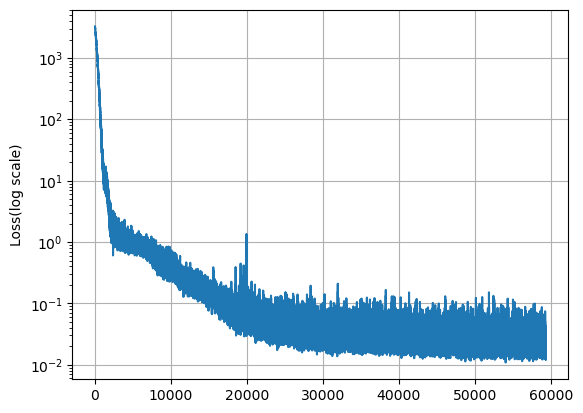

In [24]:
#plt.figure(1, figsize = [20,10])
plt.semilogy(epoch_loss)
plt.ylabel('Loss(log scale)')
plt.grid()

In [25]:
model.eval()  # Set the model to evaluation mode
with torch.no_grad():
    test_inputs = torch.tensor(inp_test_data, dtype=torch.float32).to(device)
    test_targets = torch.tensor(out_test_data, dtype=torch.float32).to(device)
    test_outputs = model(test_inputs)
    test_loss = criterion(test_outputs, test_targets)
    print(f'Test Loss: {test_loss.item():.4f}')

Test Loss: 0.0153


/tmp/ipykernel_537779/1681708791.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  test_inputs = torch.tensor(inp_test_data, dtype=torch.float32).to(device)
/tmp/ipykernel_537779/1681708791.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  test_targets = torch.tensor(out_test_data, dtype=torch.float32).to(device)


In [26]:
test_outputs.shape

torch.Size([3996, 20])

In [27]:
#torch.save(model, 'LSTM.pth')
#torch.save(model.state_dict(), 'LSTM_state_dict.pth')


In [28]:
########## CDF plots ###########
pred = test_outputs.detach().numpy()
tgt = test_targets.detach().numpy()
error = tgt - pred
#pred = pred.flatten()
#tgt = tgt.flatten()
sortd_pred, a_pred = return_cdf(pred[:,0])
sortd_tgt, a_tgt = return_cdf(tgt[:,0])


In [29]:
#plt.plot(sortd_pred, a_pred)
#plt.plot(sortd_tgt, a_tgt, alpha = 0.3)

In [30]:
tgt.shape

(3996, 20)

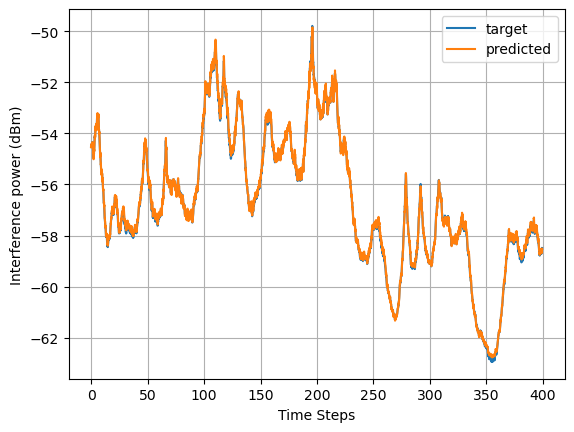

In [37]:
xticks = np.array([i for i in range(len(pred[:,0]))])
xticks = xticks/10
plt.plot(xticks, tgt[:,0], label = 'target')
plt.plot(xticks, pred[:,0], label = 'predicted')

plt.legend()
plt.ylabel('Interference power (dBm)')
plt.xlabel('Time Steps')
plt.grid()
plt.show()

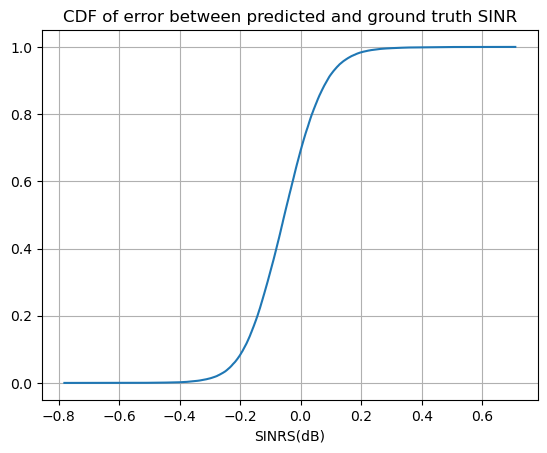

In [32]:
sortd_error, a_error = return_cdf(error.flatten())
plt.plot(sortd_error, a_error)
plt.title('CDF of error between predicted and ground truth SINR')
plt.xlabel('SINRS(dB)')
plt.grid()
plt.show()

In [40]:
'''
torch.save(model.state_dict(), 'LSTM_state_dict.pth')
# load
state_dict = torch.load('LSTM_state_dict.pth', map_location=device, weights_only=True)
model.load_state_dict(state_dict)
model.eval()
''';
